# 03 — Final Model, SHAP Interpretation, and Error Analysis

This notebook trains the final selected model after the repeated nested cross-validation comparison. The workflow performs a final 5-fold cross-validation hyperparameter search, saves the complete fitted pipeline, applies SHAP for model interpretation, and analyses validation errors to better understand false positives and false negatives.

## Import libraries, project modules, and load the dataset

In [27]:
from pathlib import Path
import sys, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import load_heart_disease, get_estimators_and_param_spaces
from src.final_model import select_best_hyperparams_cv5, train_and_save_final_pipeline, compute_shap_values, validation_error_analysis
from src import plotting

DATA_PATH = PROJECT_ROOT / 'data' / 'heart_disease.csv'
X, y = load_heart_disease(DATA_PATH)
estimators, param_spaces = get_estimators_and_param_spaces(random_state=42)

## Choose winner from notebook 02

In [28]:
WINNER_NAME = 'LDA'  # change after inspecting notebook 02 if needed
USE_FEATURE_SELECTION = False # set True if FS matched/improved rnCV performance

estimator = dict(estimators)[WINNER_NAME]
param_space = param_spaces[WINNER_NAME]
print(WINNER_NAME, estimator)

LDA LinearDiscriminantAnalysis()


## Task 5.1 — Final CV(5) hyperparameter search
### Best Parameters identification

This cell runs `select_best_hyperparams_cv5`, which builds a complete raw-data pipeline containing preprocessing and the classifier. The search uses stratified 5-fold cross-validation on all available data l and optimises the selected winning model using ROC-AUC. This step is not used for unbiased performance estimation, because that was already completed in the repeated nested cross-validation notebook. Instead, it is used to identify the best final hyperparameter configuration before training the deployable model.

The search is still leakage-safe because preprocessing is included inside the sklearn pipeline and is refitted within each cross-validation fold.
The best cross-validation score and selected hyperparameters are printed so that the final model configuration can be inspected before saving.

In [29]:
search = select_best_hyperparams_cv5(
    estimator=estimator,
    param_space=param_space,
    X=X,
    y=y,
    use_feature_selection=USE_FEATURE_SELECTION,
    feature_k_grid=[3, 5, 8, 10, 'all'],
    n_iter=60,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
)
print('Best CV score:', search.best_score_)
print('Best params:', search.best_params_)

Best CV score: 0.9119934011238359
Best params: {'classifier__shrinkage': np.float64(0.3910606075732408), 'classifier__solver': 'eigen'}


## Task 5.2 — Train and save final pipeline

After the final search, `RandomizedSearchCV(refit=True)` automatically refits the best pipeline on the full dataset. This means the final saved model uses all available training data and includes every required preprocessing step.

This cell saves the refitted best estimator as a `.pkl` file. The saved object is the complete sklearn pipeline, including preprocessing and the final classifier.

In [30]:
final_pipeline, model_path = train_and_save_final_pipeline(search, model_filename='best_model.pkl')
print(model_path)
print(final_pipeline)

C:\Users\voula\Downloads\assignment2_heart_noleak_fixed\assignment2_heart_noleak\models\best_model.pkl
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak',
                                                   'ca']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))])

## Task 5.3 — SHAP interpretation

SHAP analysis is used to explain the final trained model by estimating how much each transformed feature contributes to the model’s predictions. This helps move beyond performance metrics and provides insight into which clinical variables drive the final classifier.

SHAP is computed on the final model trained on all available data, so the explanation reflects the final deployable pipeline.

This cell transforms the dataset using the fitted preprocessing pipeline and computes SHAP values for the final classifier. Because LDA is a linear model, a linear SHAP explainer is appropriate.

The SHAP summary plot ranks features by their average contribution to the model’s predictions, helping identify the most influential predictors in the final model.

(242, 22)


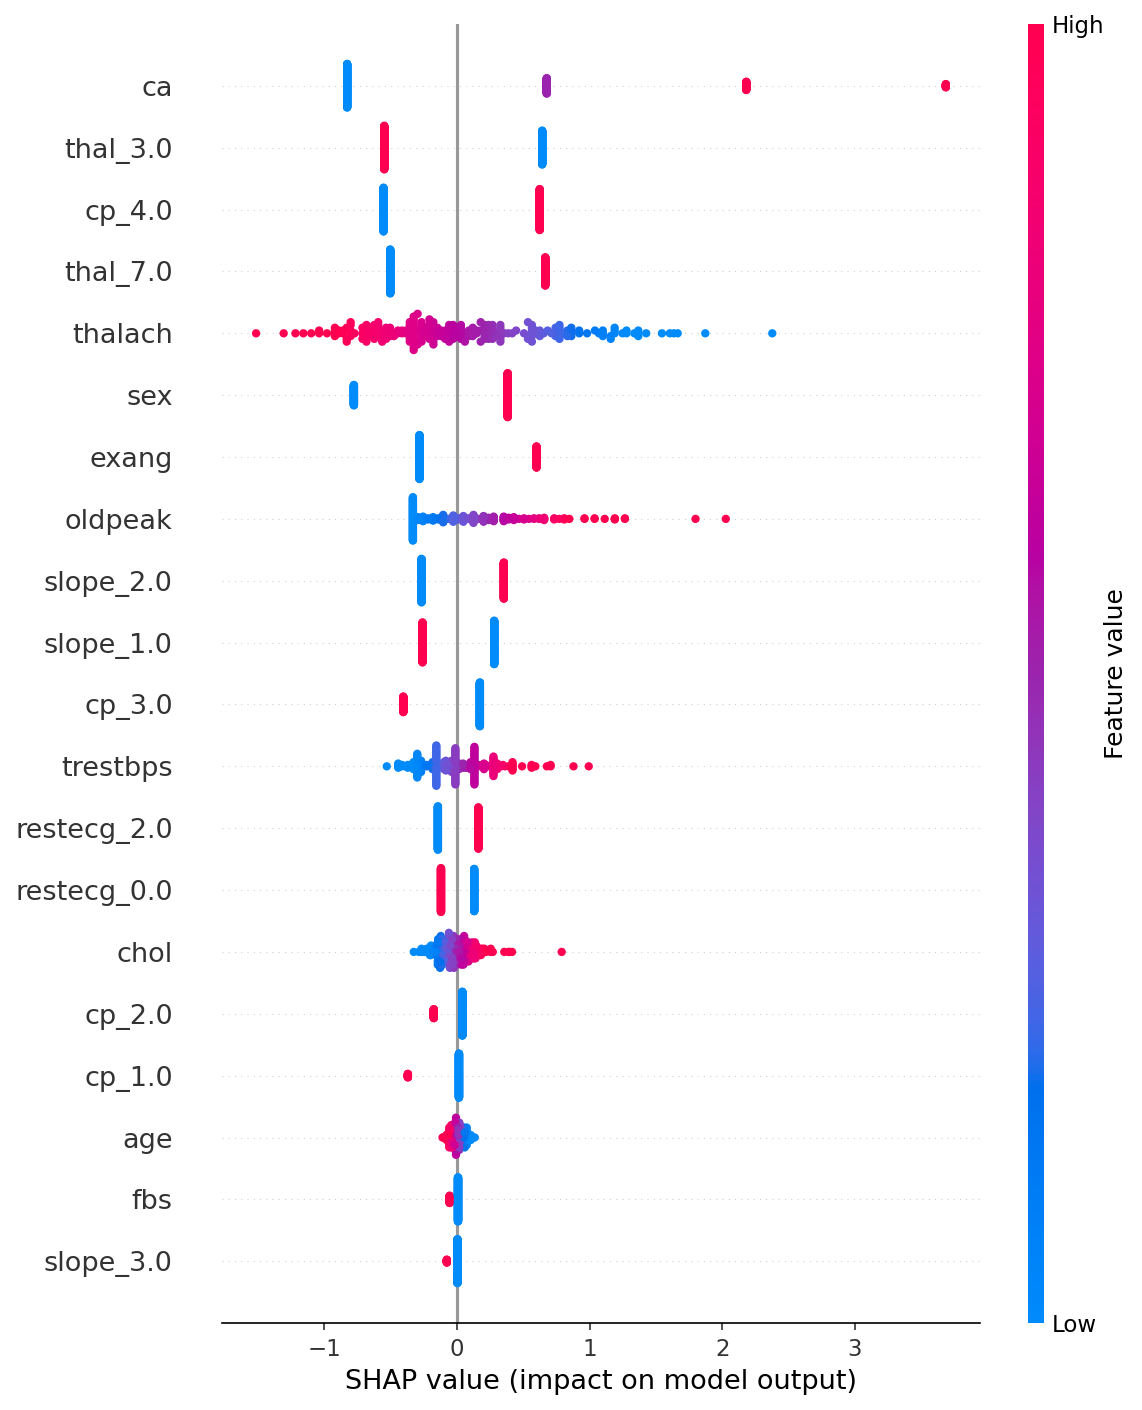

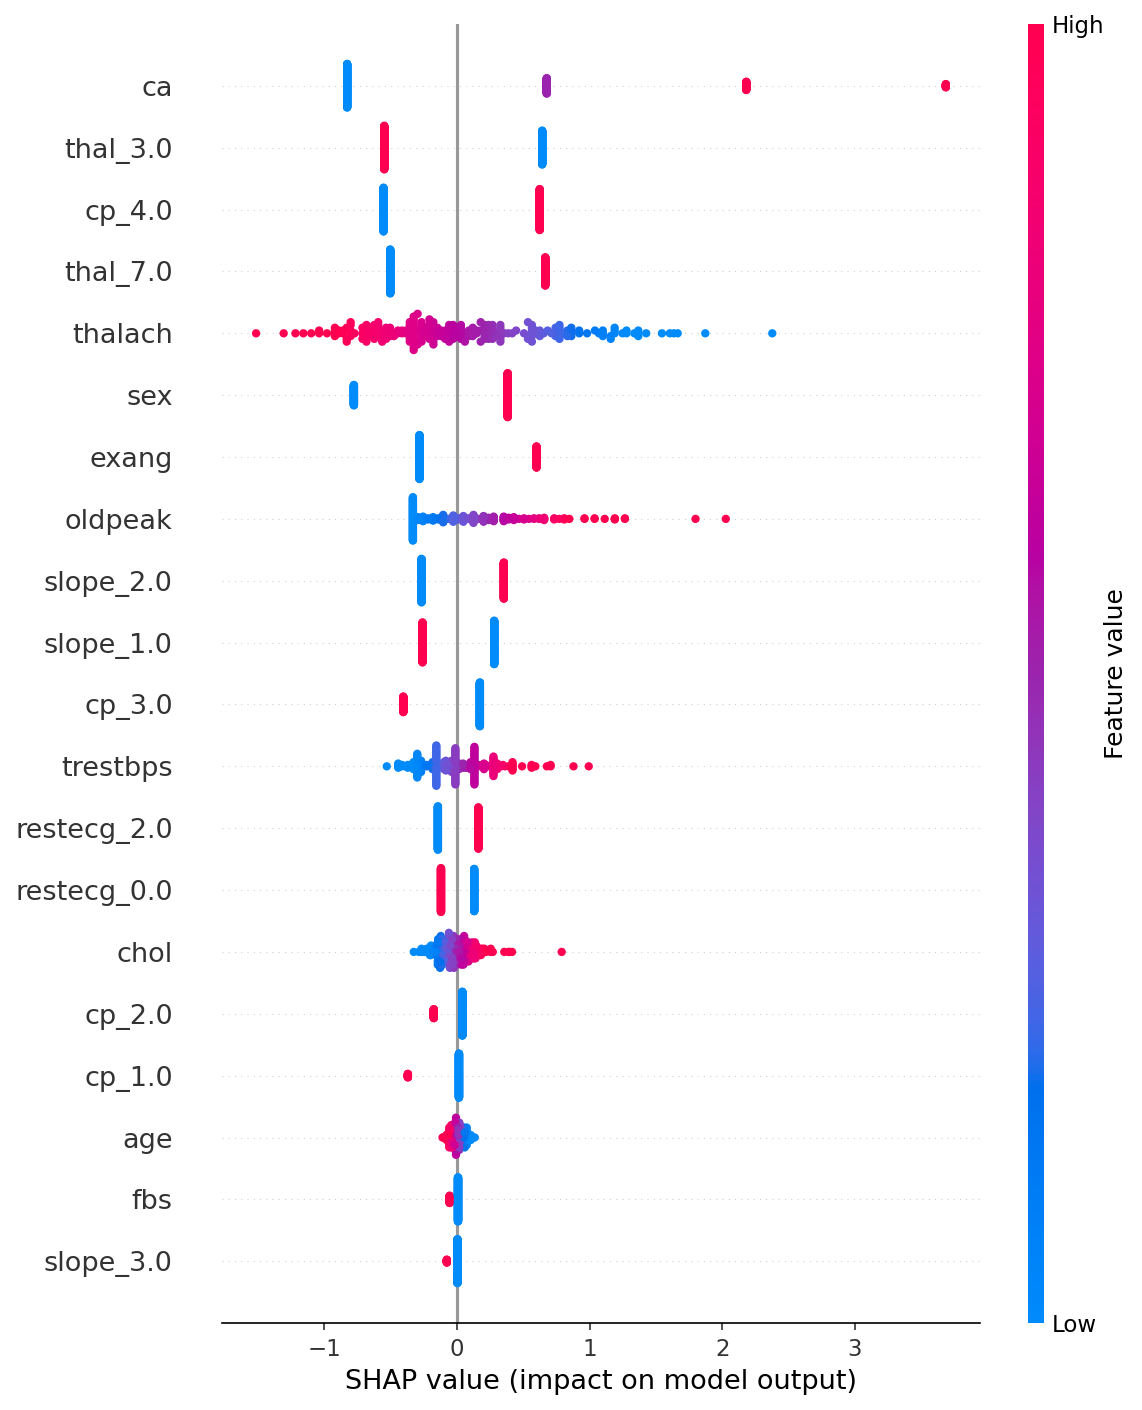

In [31]:
shap_values, X_model, explainer = compute_shap_values(final_pipeline, X)
print(X_model.shape)
plotting.plot_shap_summary(shap_values, X_model)

### Interpretation of SHAP summary plot

The most influential predictors were `ca`, `thal`, and asymptomatic chest pain (`cp_4.0`), which consistently pushed predictions toward the heart disease class when their values were high or abnormal. Exercise-related variables such as `thalach`, `exang`, `oldpeak`, and `slope` also showed strong influence, highlighting the importance of cardiac stress response in disease prediction.

For continuous variables such as `thalach` and `oldpeak`, the colour gradient reveals the direction of the effect. Lower maximum heart rate (`thalach`) generally increased predicted disease risk, while higher ST depression (`oldpeak`) pushed predictions more strongly toward the positive heart disease class. In contrast, variables such as `age`, `fbs`, and `slope_3.0` had relatively small SHAP magnitudes, indicating weaker overall influence on the final model.

Overall, the SHAP explanations align closely with the earlier EDA and feature selection findings, supporting both the clinical validity and interpretability of the final LDA classifier.

## Bonus — validation error analysis
This section investigates where the final model makes correct and incorrect predictions. A stratified train-validation split (80-20) is created so that both classes remain proportionally represented. The final pipeline is trained on the training subset and evaluated on the validation subset.

The classification report and confusion matrix provide a direct view of prediction quality, including precision, recall, and the number of false positive and false negative cases.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

bonus_pipeline = final_pipeline
bonus_pipeline.fit(X_train_b, y_train_b)

y_pred_b = bonus_pipeline.predict(X_val_b)

if hasattr(bonus_pipeline, "predict_proba"):
    y_prob_b = bonus_pipeline.predict_proba(X_val_b)[:, 1]
else:
    y_prob_b = bonus_pipeline.decision_function(X_val_b)

print(classification_report(y_val_b, y_pred_b))
print(confusion_matrix(y_val_b, y_pred_b))

              precision    recall  f1-score   support

           0       0.86      0.93      0.89        27
           1       0.90      0.82      0.86        22

    accuracy                           0.88        49
   macro avg       0.88      0.87      0.88        49
weighted avg       0.88      0.88      0.88        49

[[25  2]
 [ 4 18]]


### Interpretation of validation classification results

For the healthy class (`0`), the model achieved a precision of 0.86 and a recall of 0.93, indicating that most healthy patients were identified correctly with relatively few false positives. For the heart disease class (`1`), the model achieved a precision of 0.90 and a recall of 0.82, showing strong ability to identify disease cases while maintaining high prediction confidence.

In [33]:
error_df = X_val_b.copy()
error_df["true_label"] = y_val_b.values
error_df["pred_label"] = y_pred_b
error_df["pred_probability"] = y_prob_b

def assign_group(row):
    if row["true_label"] == 1 and row["pred_label"] == 1:
        return "TP"
    if row["true_label"] == 0 and row["pred_label"] == 0:
        return "TN"
    if row["true_label"] == 0 and row["pred_label"] == 1:
        return "FP"
    if row["true_label"] == 1 and row["pred_label"] == 0:
        return "FN"

error_df["error_group"] = error_df.apply(assign_group, axis=1)
error_df["correct"] = error_df["true_label"] == error_df["pred_label"]

display(error_df["error_group"].value_counts())
display(error_df.groupby("error_group")[["age", "trestbps", "chol", "thalach", "oldpeak"]].describe())

error_group
TN    25
TP    18
FN     4
FP     2
Name: count, dtype: int64

age                                                       \
            count       mean       std   min    25%   50%    75%   max   
error_group                                                              
FN            4.0  51.750000  7.544314  41.0  49.25  54.5  57.00  57.0   
FP            2.0  55.500000  2.121320  54.0  54.75  55.5  56.25  57.0   
TN           25.0  53.200000  9.004628  37.0  48.00  53.0  59.00  71.0   
TP           18.0  57.666667  8.858363  38.0  54.00  57.5  60.00  77.0   

            trestbps         ... thalach        oldpeak                      \
               count   mean  ...     75%    max   count      mean       std   
error_group                  ...                                              
FN               4.0  126.5  ...  166.50  174.0     4.0  0.000000  0.000000   
FP               2.0  126.0  ...  162.75  168.0     2.0  0.200000  0.282843   
TN              25.0  131.0  ...  172.00  190.0    25.0  0.412000  0.611228   
TP              18.0  134.5  ...  158.50  182.0    18.0  1.738889  1.597107   

                                          
             min    25%   50%   75%  max  
error_group                               
FN           0.0  0.000  0.00  0.00  0.0  
FP           0.0  0.100  0.20  0.30  0.4  
TN           0.0  0.000  0.00  0.60  1.9  
TP           0.0  0.275  1.35  2.75  5.6  

[4 rows x 40 columns]

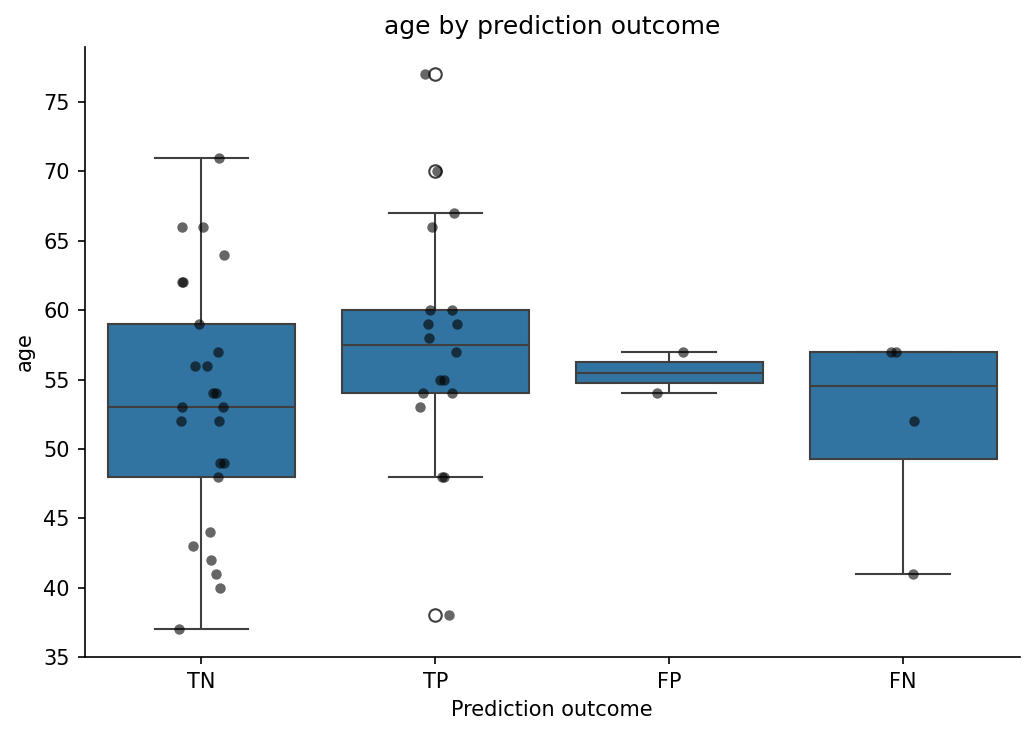

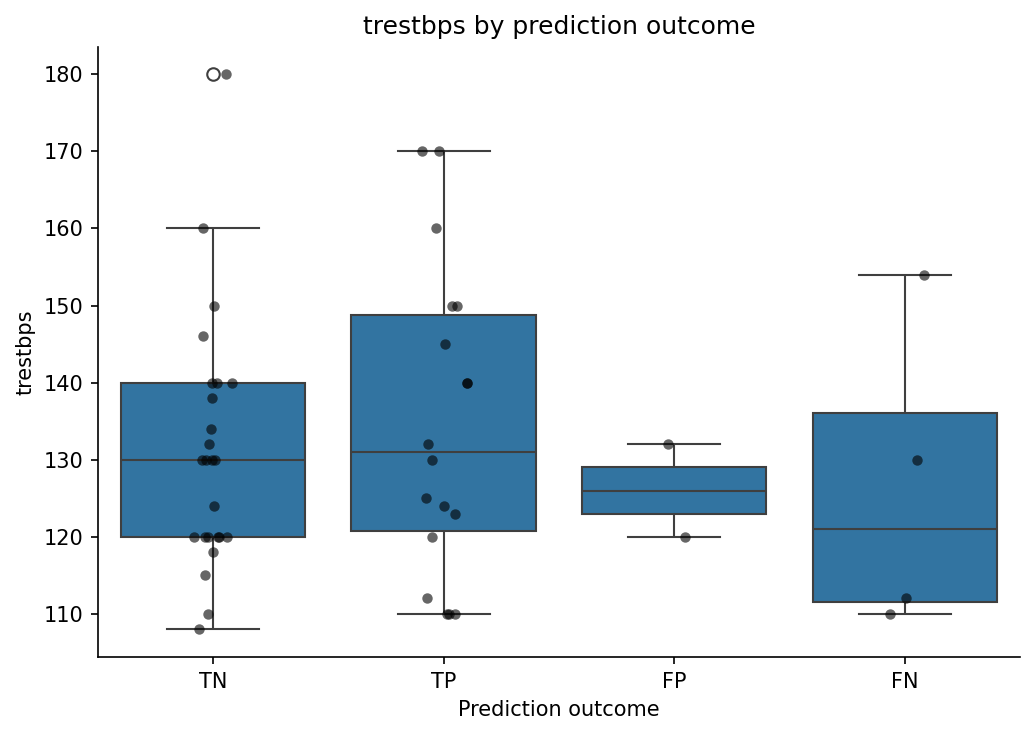

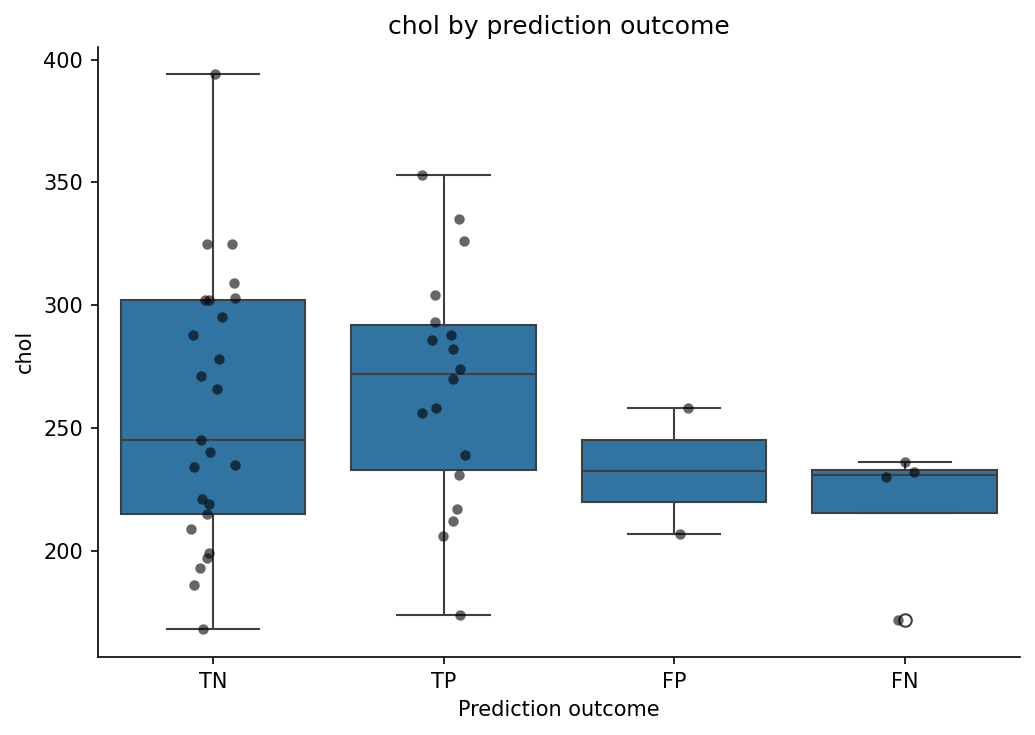

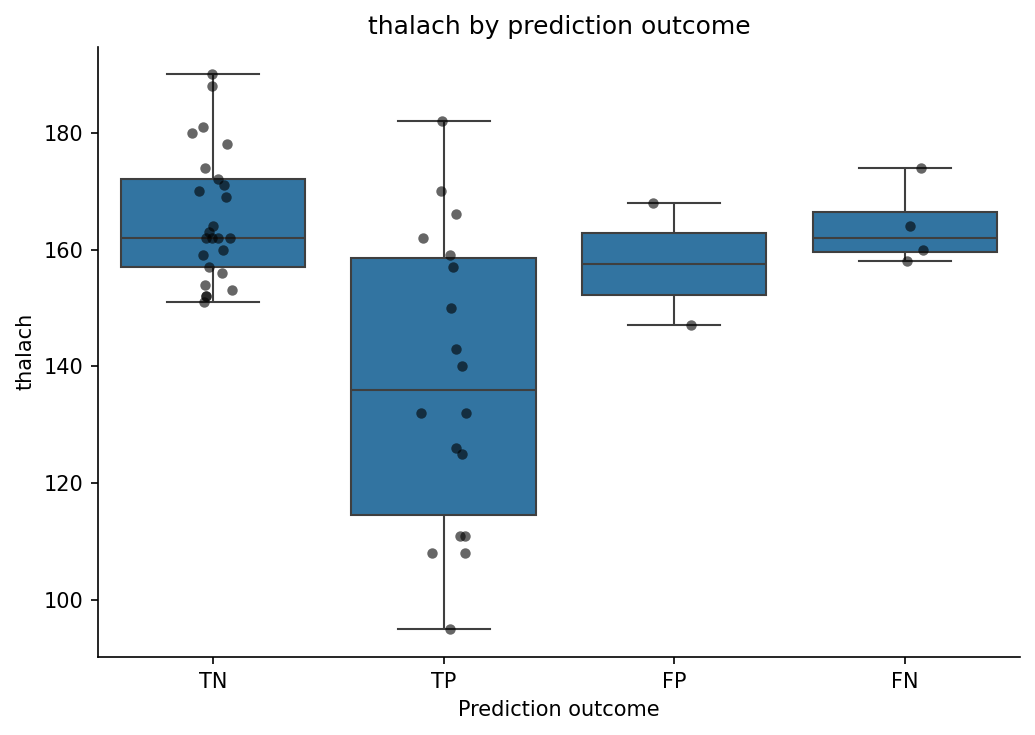

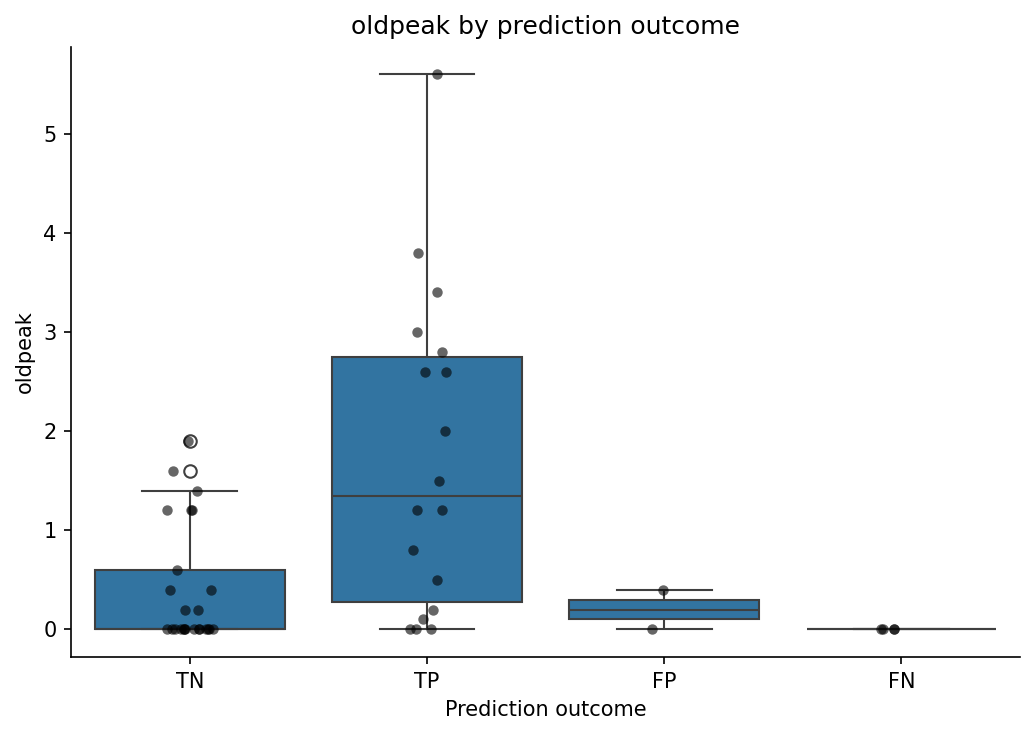

In [35]:
clinical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

for feature in clinical_features:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=error_df, x="error_group", y=feature, order=["TN", "TP", "FP", "FN"])
    sns.stripplot(data=error_df, x="error_group", y=feature, order=["TN", "TP", "FP", "FN"], color="black", alpha=0.6)
    plt.title(f"{feature} by prediction outcome")
    plt.xlabel("Prediction outcome")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "figures" / f"bonus_{feature}_error_groups.png", dpi=150)
    plt.show()

### Interpretation of clinical feature distributions across prediction outcomes

The error-group visualisations show noticeable differences between correctly and incorrectly classified patients. True positive cases generally exhibit lower maximum heart rate (`thalach`) and higher ST depression (`oldpeak`), both of which are clinically associated with heart disease. False positives and false negatives appear to have feature values that overlap with both healthy and diseased groups, suggesting that these patients display more ambiguous clinical profiles. Variables such as cholesterol and resting blood pressure show weaker separation between outcome groups, while exercise-related features appear more informative for distinguishing correctly and incorrectly classified cases.

## Compute SHAP values for validation cases

This cell computes SHAP values specifically for the validation subset used in the error analysis. The SHAP values are stored together with each case’s prediction outcome and correctness label.

This allows model explanations to be compared between correct and incorrect predictions.

In [36]:
shap_values_b, X_model_b, explainer_b = compute_shap_values(bonus_pipeline, X_val_b)

shap_error_df = pd.DataFrame(
    shap_values_b,
    columns=X_model_b.columns,
    index=X_val_b.index
)

shap_error_df["error_group"] = error_df["error_group"].values
shap_error_df["correct"] = error_df["correct"].values

display(shap_error_df.head())

,age,trestbps,chol,thalach,oldpeak,ca,sex,fbs,exang,cp_1.0,...,restecg_1.0,restecg_2.0,slope_1.0,slope_2.0,slope_3.0,thal_3.0,thal_6.0,thal_7.0,error_group,correct
0,-0.007571,-0.119363,0.092673,-0.263383,-0.117421,-0.705549,0.266936,0.001357,-0.335704,0.042219,...,-0.0,0.095250,0.294485,0.418328,0.010683,0.692006,-0.001793,0.664738,TP,True
187,-0.003128,-0.181256,0.359481,-0.405727,-0.216055,-0.705549,0.266936,0.001357,-0.335704,0.042219,...,-0.0,-0.099218,-0.332896,-0.313746,0.010683,-0.519004,-0.001793,-0.458440,TN,True
171,-0.015345,-0.335986,-0.440943,-0.073592,-0.281811,-0.705549,0.266936,0.001357,-0.335704,0.042219,...,-0.0,0.095250,-0.332896,-0.313746,0.010683,0.692006,-0.001793,0.664738,FN,False
3,-0.000907,-0.366932,0.275776,-0.026145,-0.281811,-0.705549,0.266936,0.001357,-0.335704,0.042219,...,-0.0,-0.099218,-0.332896,-0.313746,0.010683,0.692006,-0.001793,0.664738,TN,True
207,-0.003128,-0.212202,-0.367702,-0.832756,-0.281811,-0.705549,0.266936,0.001357,-0.335704,-0.371528,...,-0.0,0.095250,0.294485,0.418328,0.010683,0.692006,0.086040,-0.458440,TN,True


This cell calculates the mean absolute SHAP value for each feature separately for correct and incorrect predictions. This helps identify which features have stronger influence in cases where the model makes errors.

Large SHAP values in incorrect predictions may indicate features that push the model strongly toward the wrong class.

In [37]:
shap_feature_cols = X_model_b.columns

mean_abs_shap = (
    shap_error_df
    .groupby("correct")[shap_feature_cols]
    .apply(lambda df: df.abs().mean())
    .T
)

mean_abs_shap.columns = ["Incorrect", "Correct"] if False in mean_abs_shap.columns else mean_abs_shap.columns
display(mean_abs_shap.sort_values(by=mean_abs_shap.columns[0], ascending=False).head(15))

,Incorrect,Correct
ca,0.664845,0.957351
thal_3.0,0.605505,0.591424
thal_7.0,0.561589,0.540000
cp_4.0,0.554863,0.554600
sex,0.376137,0.419309
exang,0.368097,0.417062
slope_2.0,0.348606,0.359956
slope_1.0,0.320093,0.311458
oldpeak,0.259892,0.325065
thalach,0.226991,0.407674


## Quantify SHAP differences between correct and incorrect predictions

This cell compares average feature contributions between correctly and incorrectly classified cases. The difference score highlights which features contribute more strongly to misclassified predictions.

In [38]:
correct_shap = shap_error_df.loc[shap_error_df["correct"] == True, shap_feature_cols].abs().mean()
incorrect_shap = shap_error_df.loc[shap_error_df["correct"] == False, shap_feature_cols].abs().mean()

shap_compare = pd.DataFrame({
    "Correct_mean_abs_SHAP": correct_shap,
    "Incorrect_mean_abs_SHAP": incorrect_shap,
    "Difference_incorrect_minus_correct": incorrect_shap - correct_shap
}).sort_values("Difference_incorrect_minus_correct", ascending=False)

display(shap_compare.head(15))
shap_compare.to_csv(PROJECT_ROOT / "results" / "bonus_shap_correct_vs_incorrect.csv")

,Correct_mean_abs_SHAP,Incorrect_mean_abs_SHAP,Difference_incorrect_minus_correct
cp_3.0,0.099063,0.132039,0.032976
thal_7.0,0.540000,0.561589,0.021589
thal_3.0,0.591424,0.605505,0.014082
slope_1.0,0.311458,0.320093,0.008635
cp_2.0,0.054059,0.057161,0.003102
cp_4.0,0.554600,0.554863,0.000263
restecg_1.0,0.000000,0.000000,0.000000
restecg_0.0,0.063890,0.063425,-0.000465
restecg_2.0,0.097280,0.096573,-0.000708
fbs,0.002715,0.001357,-0.001357


## Visualise features associated with misclassification

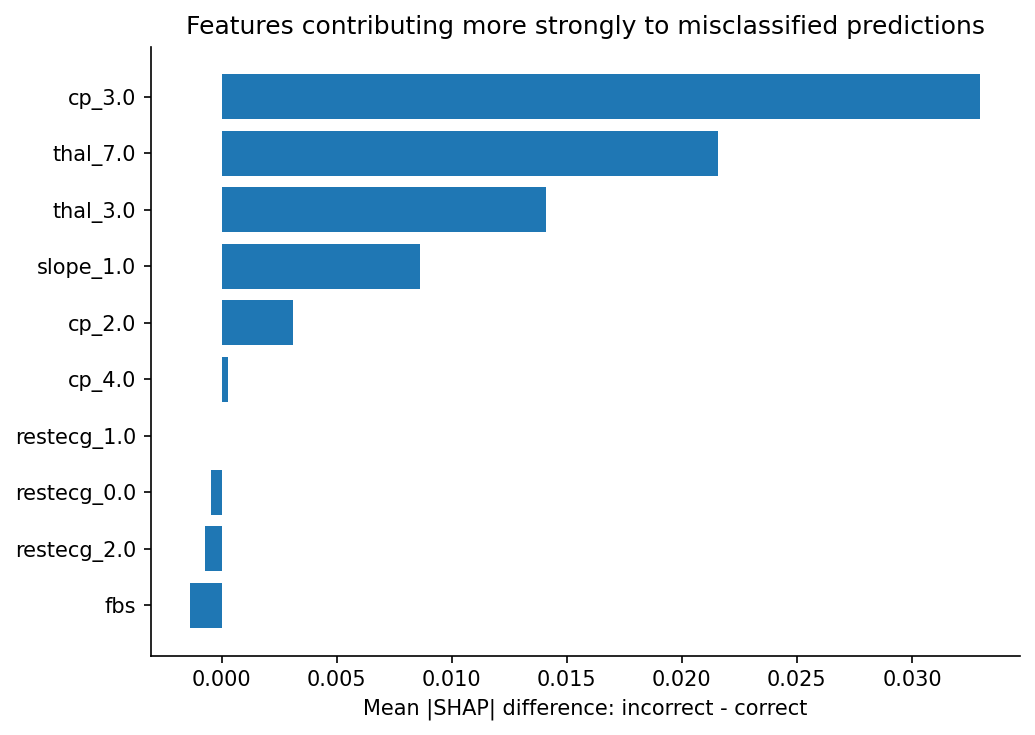

In [39]:
top_shap_diff = shap_compare.head(10).sort_values("Difference_incorrect_minus_correct")

plt.figure(figsize=(7, 5))
plt.barh(top_shap_diff.index, top_shap_diff["Difference_incorrect_minus_correct"])
plt.xlabel("Mean |SHAP| difference: incorrect - correct")
plt.title("Features contributing more strongly to misclassified predictions")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "bonus_shap_error_difference.png", dpi=150)
plt.show()

### Interpretation of features contributing more strongly to misclassified predictions

The SHAP difference plot highlights the features whose contributions increase most strongly in misclassified cases relative to correctly classified predictions. Features related to chest pain type (`cp_3.0`), thalassemia categories (`thal_7.0`, `thal_3.0`), and ST segment slope (`slope_1.0`) showed the largest increases in mean absolute SHAP values during incorrect predictions.

This suggests that these features may create more ambiguous decision boundaries for the classifier, particularly in patients whose clinical profiles overlap between healthy and diseased classes. However, the overall magnitude of the differences remains relatively small, indicating that the final LDA model maintains stable behaviour even in difficult classification cases.

## Compare SHAP explanations for false positives and false negatives

This cell separately compares SHAP contributions for false positive and false negative predictions. This distinction is important in medical classification because the two error types have different clinical implications.

False positives may indicate patients incorrectly flagged as diseased, while false negatives represent missed disease cases. Comparing their SHAP profiles helps identify whether different features contribute to each type of error.

In [40]:
fp_shap = shap_error_df.loc[shap_error_df["error_group"] == "FP", shap_feature_cols].abs().mean()
fn_shap = shap_error_df.loc[shap_error_df["error_group"] == "FN", shap_feature_cols].abs().mean()

fp_fn_compare = pd.DataFrame({
    "FP_mean_abs_SHAP": fp_shap,
    "FN_mean_abs_SHAP": fn_shap,
    "FN_minus_FP": fn_shap - fp_shap
}).sort_values("FN_minus_FP", ascending=False)

display(fp_fn_compare.head(15))
fp_fn_compare.to_csv(PROJECT_ROOT / "results" / "bonus_fp_vs_fn_shap.csv")

,FP_mean_abs_SHAP,FN_mean_abs_SHAP,FN_minus_FP
sex,0.266936,0.430737,0.163802
trestbps,0.092838,0.253095,0.160257
chol,0.133404,0.202908,0.069505
oldpeak,0.216055,0.281811,0.065756
cp_2.0,0.038107,0.066688,0.028581
slope_1.0,0.313691,0.323294,0.009603
age,0.001666,0.005831,0.004165
thal_6.0,0.001793,0.001793,0.000000
slope_3.0,0.010683,0.010683,0.000000
cp_1.0,0.042219,0.042219,0.000000


### Interpretation of SHAP differences between false positives and false negatives

The false positive versus false negative SHAP comparison shows that several features contribute more strongly to missed disease cases (false negatives) than to incorrectly flagged healthy cases (false positives). In particular, `sex`, `trestbps`, `chol`, and `oldpeak` exhibited larger SHAP magnitudes in false negative predictions.

This suggests that some diseased patients with less extreme or overlapping cardiovascular measurements may be harder for the classifier to distinguish from healthy individuals. In contrast, features such as chest pain type and thalassemia contributed similarly across both error categories, indicating more stable influence regardless of prediction outcome.